In [1]:
# =============================================================
# ERA COMPARISON PROJECT - Notebook 6: Event Analysis
#
# Core Question: When the same market event occurs, how do
# the three eras of models react differently?
#
# This analysis moves beyond aggregate performance metrics
# and examines model BEHAVIOR at specific critical moments.
#
# Three events studied:
# 1. COVID Crash (Feb-Apr 2020): extreme single-direction drop
# 2. COVID Recovery (Apr-Jun 2020): sharp reversal after crash
# 3. Rate Hike Selloff (Jan-Mar 2022): macro-driven slow decline
#
# For each event, we ask:
# - What signal did each model generate?
# - Did it protect capital or stay invested?
# - What does its reaction reveal about its limitations?
# =============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

ticker = 'AAPL'
data = yf.download(ticker, start='2014-01-01', end='2024-01-01')
prices = data['Close'].squeeze()
volume = data['Volume'].squeeze()

print("Data loaded successfully.")
print(f"Total trading days: {len(prices)}")

[*********************100%***********************]  1 of 1 completed

Data loaded successfully.
Total trading days: 2516


In [2]:
# =============================================================
# REBUILD ALL THREE SIGNALS
# (Same logic as notebook 05, reproduced here for self-containment)
# =============================================================

# -------- ERA 1: MA Crossover --------
short_ma = prices.rolling(20).mean()
long_ma = prices.rolling(50).mean()
signal_ma = (short_ma > long_ma).astype(int)

# -------- ERA 2: Random Forest --------
def build_features(prices, volume):
    df = pd.DataFrame()
    for lag in [1, 2, 3, 5, 10]:
        df[f'return_{lag}d'] = prices.pct_change(lag)
    for window in [10, 20, 50]:
        df[f'ma_ratio_{window}'] = prices / prices.rolling(window).mean() - 1
    delta = prices.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi'] = 100 - (100 / (1 + gain / loss))
    df['volatility_20'] = prices.pct_change().rolling(20).std()
    df['volume_ratio'] = volume / volume.rolling(20).mean()
    df['target'] = (prices.shift(-1) > prices).astype(int)
    return df.dropna()

df_features = build_features(prices, volume)
feature_cols = [c for c in df_features.columns if c != 'target']
X = df_features[feature_cols]
y = df_features['target']
split = int(len(df_features) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=5,
    min_samples_leaf=20, random_state=42)
rf_model.fit(X_train, y_train)

# Generate RF signal for the FULL period using a rolling approach
# For dates in training period: use in-sample predictions
# For dates in test period: use out-of-sample predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)
signal_rf_full = pd.Series(
    np.concatenate([y_pred_train, y_pred_test]),
    index=df_features.index,
    dtype=float
)

# -------- ERA 3: Transformer --------
returns = prices.pct_change().dropna().values
scaler = MinMaxScaler()
returns_scaled = scaler.fit_transform(returns.reshape(-1, 1)).flatten()

SEQ_LEN = 60
SPLIT_IDX = int(len(returns_scaled) * 0.8)

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len
    def __len__(self):
        return len(self.data) - self.seq_len
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.seq_len]
        y = self.data[idx + self.seq_len]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor([y])

class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_projection = nn.Linear(1, 64)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=4, dim_feedforward=256,
            dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.output_projection = nn.Linear(64, 1)
    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer(x)
        return self.output_projection(x[:, -1, :])

# Train on full data to get signals for entire period
full_loader = DataLoader(
    TimeSeriesDataset(returns_scaled, SEQ_LEN),
    batch_size=32, shuffle=False)
train_loader = DataLoader(
    TimeSeriesDataset(returns_scaled[:SPLIT_IDX], SEQ_LEN),
    batch_size=32, shuffle=True)

model = TransformerModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(50):
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(x_batch), y_batch)
        loss.backward()
        optimizer.step()

model.eval()
tf_predictions_full = []
with torch.no_grad():
    for x_batch, _ in full_loader:
        pred = model(x_batch)
        tf_predictions_full.extend(pred.numpy().flatten())

tf_preds_real = scaler.inverse_transform(
    np.array(tf_predictions_full).reshape(-1, 1)).flatten()

# Align transformer signal with price dates
tf_dates = prices.index[SEQ_LEN + 1: SEQ_LEN + 1 + len(tf_preds_real)]
signal_tf_full = pd.Series(
    (tf_preds_real > 0).astype(float),
    index=tf_dates
)

print("All three signals generated for full period.")

All three signals generated for full period.


In [7]:
# =============================================================
# EVENT ANALYSIS FUNCTION
#
# For each market event, this function creates a 3-panel chart:
#
# Panel 1: Price during the event window
#   Shows what actually happened in the market
#   Colored background: red = price falling, green = rising
#
# Panel 2: Signal from each model (1=invested, 0=cash)
#   Shows what each model DECIDED to do during this period
#   This is the core of the analysis
#
# Panel 3: Daily returns
#   Shows the volatility profile of the event
#   Helps explain why certain signals were hard to get right
# =============================================================

def analyze_event(event_name, start_date, end_date, description, filename):
    """
    Visualize how each model behaved during a specific market event.
    
    Parameters:
        event_name: title for the chart
        start_date: start of event window (string 'YYYY-MM-DD')
        end_date: end of event window (string 'YYYY-MM-DD')
        description: one-line explanation of what happened
        filename: output filename for saving
    """
    # Extract event window for each signal
    event_prices = prices[start_date:end_date]
    event_returns = event_prices.pct_change()
    
    # Align signals to event window
    # Some signals may not cover the full date range
    def get_signal_for_event(signal, dates):
        aligned = signal.reindex(dates)
        return aligned.fillna(method='ffill').fillna(0)
    
    sig_ma = get_signal_for_event(signal_ma, event_prices.index)
    sig_rf = get_signal_for_event(signal_rf_full, event_prices.index)
    sig_tf = get_signal_for_event(signal_tf_full, event_prices.index)
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(f'Event Analysis: {event_name}\n"{description}"',
                 fontsize=13, fontweight='bold')
    
    # ---- Panel 1: Price ----
    axes[0].plot(event_prices.index, event_prices.values,
                 color='black', linewidth=2, label='AAPL Price')
    
    # Color background based on price direction
    for i in range(1, len(event_prices)):
        color = '#ffebee' if event_prices.iloc[i] < event_prices.iloc[i-1] else '#e8f5e9'
        axes[0].axvspan(event_prices.index[i-1], event_prices.index[i],
                       alpha=0.3, color=color)
    
    axes[0].set_title('Market Price', fontsize=11)
    axes[0].set_ylabel('Price ($)')
    axes[0].grid(True, alpha=0.3)
    
    # ---- Panel 2: Model Signals ----
    # Each model's signal plotted as a step function
    # 1 = model is invested, 0 = model is in cash
    axes[1].step(sig_ma.index, sig_ma.values,
                 label='Era 1: MA Crossover', color='#2196F3',
                 linewidth=2, where='post')
    axes[1].step(sig_rf.index, sig_rf.values + 0.05,
                 label='Era 2: Random Forest', color='#FF9800',
                 linewidth=2, where='post', linestyle='--')
    axes[1].step(sig_tf.index, sig_tf.values + 0.1,
                 label='Era 3: Transformer', color='#F44336',
                 linewidth=2, where='post', linestyle=':')
    
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['Cash (0)', 'Invested (1)'])
    axes[1].set_title('Model Signals: 1 = Hold Stock, 0 = Stay in Cash',
                      fontsize=11)
    axes[1].legend(loc='upper right', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(-0.2, 1.4)
    
    # ---- Panel 3: Daily Returns ----
    colors = ['#d32f2f' if r < 0 else '#388e3c' 
              for r in event_returns.fillna(0)]
    axes[2].bar(event_returns.index, event_returns.values,
                color=colors, alpha=0.7)
    axes[2].axhline(y=0, color='black', linewidth=0.8)
    axes[2].set_title('Daily Returns (Red = Down, Green = Up)', fontsize=11)
    axes[2].set_ylabel('Daily Return')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../results/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print signal statistics for this event
    print(f"\n=== {event_name}: Signal Statistics ===")
    print(f"Days invested - Era 1 (MA):          {int(sig_ma.sum())} / {len(sig_ma)} days")
    print(f"Days invested - Era 2 (RF):           {int(sig_rf.sum())} / {len(sig_rf)} days")
    print(f"Days invested - Era 3 (Transformer):  {int(sig_tf.sum())} / {len(sig_tf)} days")
    price_change = (event_prices.iloc[-1] / event_prices.iloc[0] - 1) * 100
    print(f"Actual price change during event:      {price_change:.1f}%")

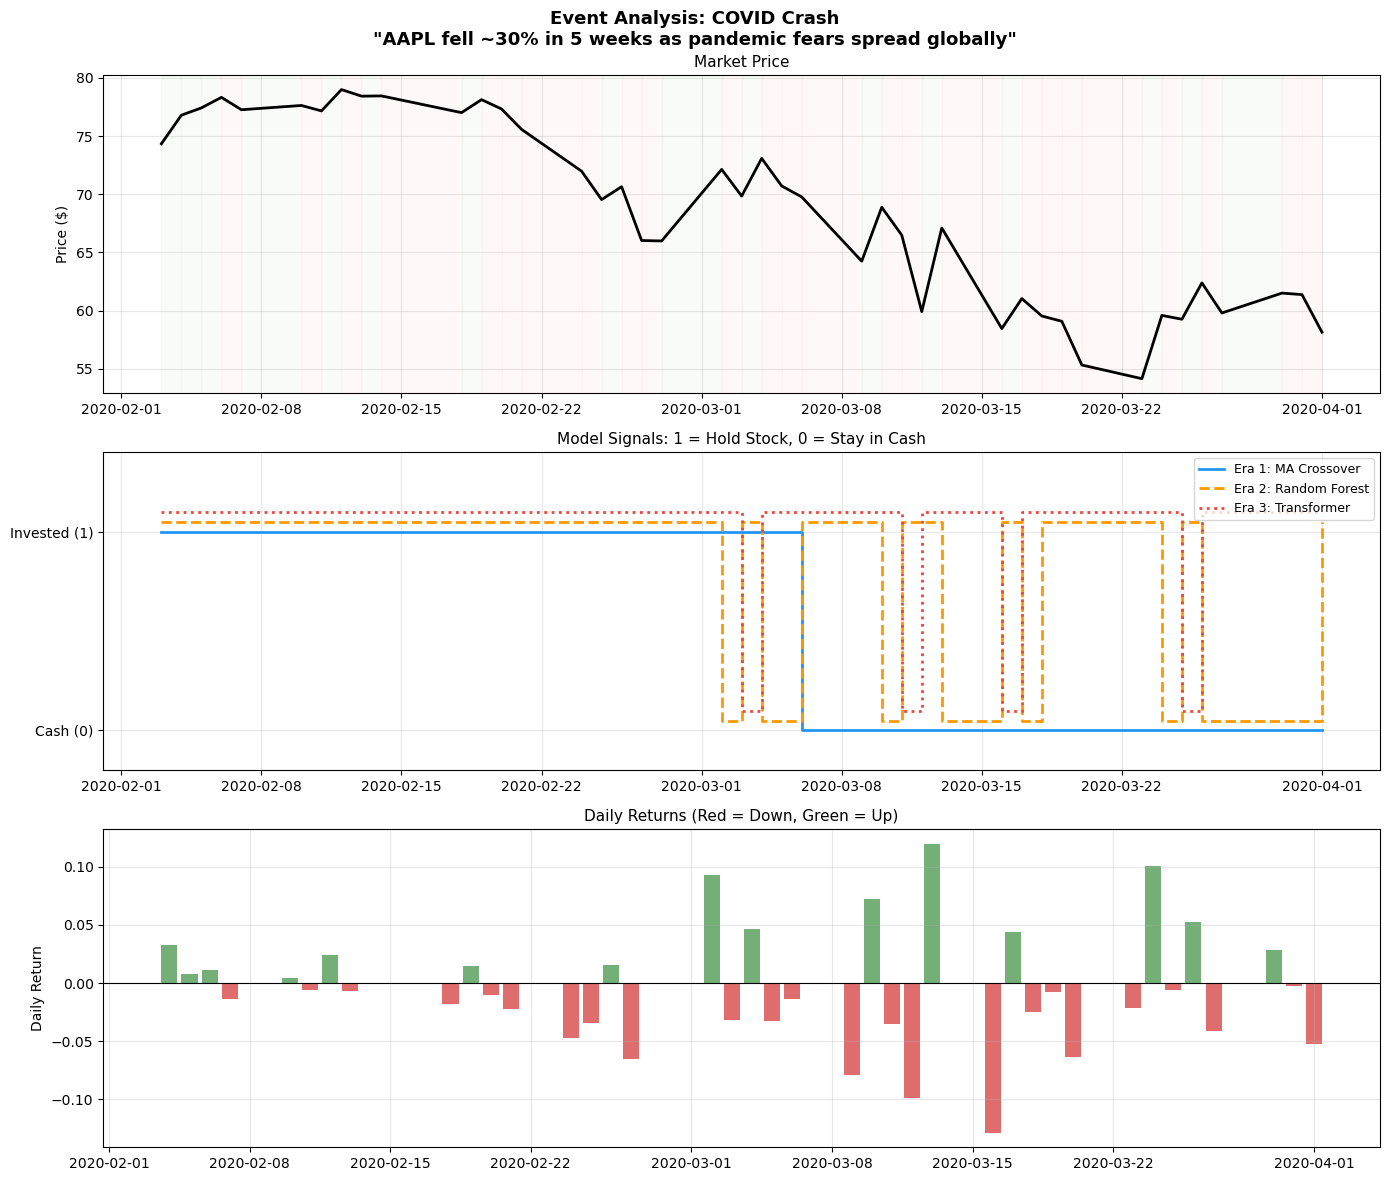


=== COVID Crash: Signal Statistics ===
Days invested - Era 1 (MA):          23 / 42 days
Days invested - Era 2 (RF):           31 / 42 days
Days invested - Era 3 (Transformer):  38 / 42 days
Actual price change during event:      -21.8%


In [8]:
# =============================================================
# EVENT 1: COVID CRASH
#
# What happened: AAPL fell ~30% in 5 weeks as COVID panic set in.
# The key question: did any model get out before the worst of it?
#
# What to look for in the signal chart:
# - Did the model switch to 0 (cash) early enough?
# - Or did it stay invested (1) all the way down?
# =============================================================

analyze_event(
    event_name="COVID Crash",
    start_date="2020-02-01",
    end_date="2020-04-01",
    description="AAPL fell ~30% in 5 weeks as pandemic fears spread globally",
    filename="12_event_covid_crash.png"
)

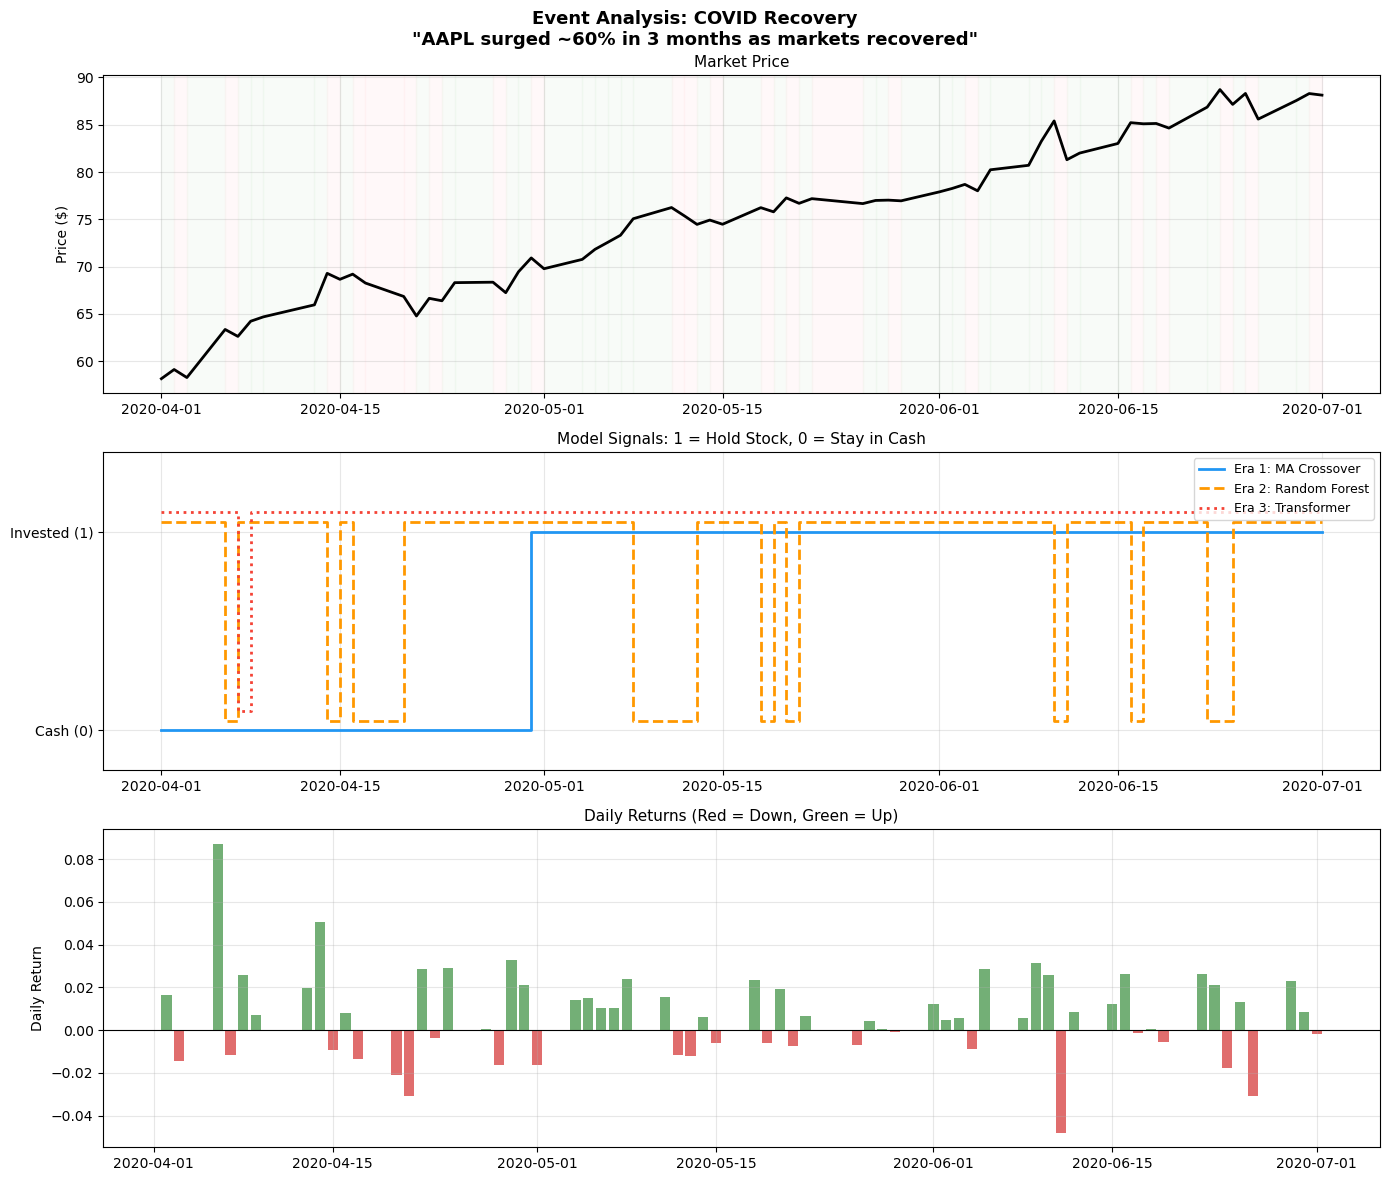


=== COVID Recovery: Signal Statistics ===
Days invested - Era 1 (MA):          44 / 64 days
Days invested - Era 2 (RF):           51 / 64 days
Days invested - Era 3 (Transformer):  63 / 64 days
Actual price change during event:      51.5%


In [9]:
# =============================================================
# EVENT 2: COVID RECOVERY
#
# What happened: After the crash, AAPL rebounded sharply,
# eventually recovering all losses and reaching new highs.
# The key question: did any model catch the reversal?
#
# What to look for:
# - Did the model switch back to 1 (invested) quickly?
# - Or did it stay in cash (0) and miss the recovery?
# =============================================================

analyze_event(
    event_name="COVID Recovery",
    start_date="2020-04-01",
    end_date="2020-07-01",
    description="AAPL surged ~60% in 3 months as markets recovered",
    filename="13_event_covid_recovery.png"
)

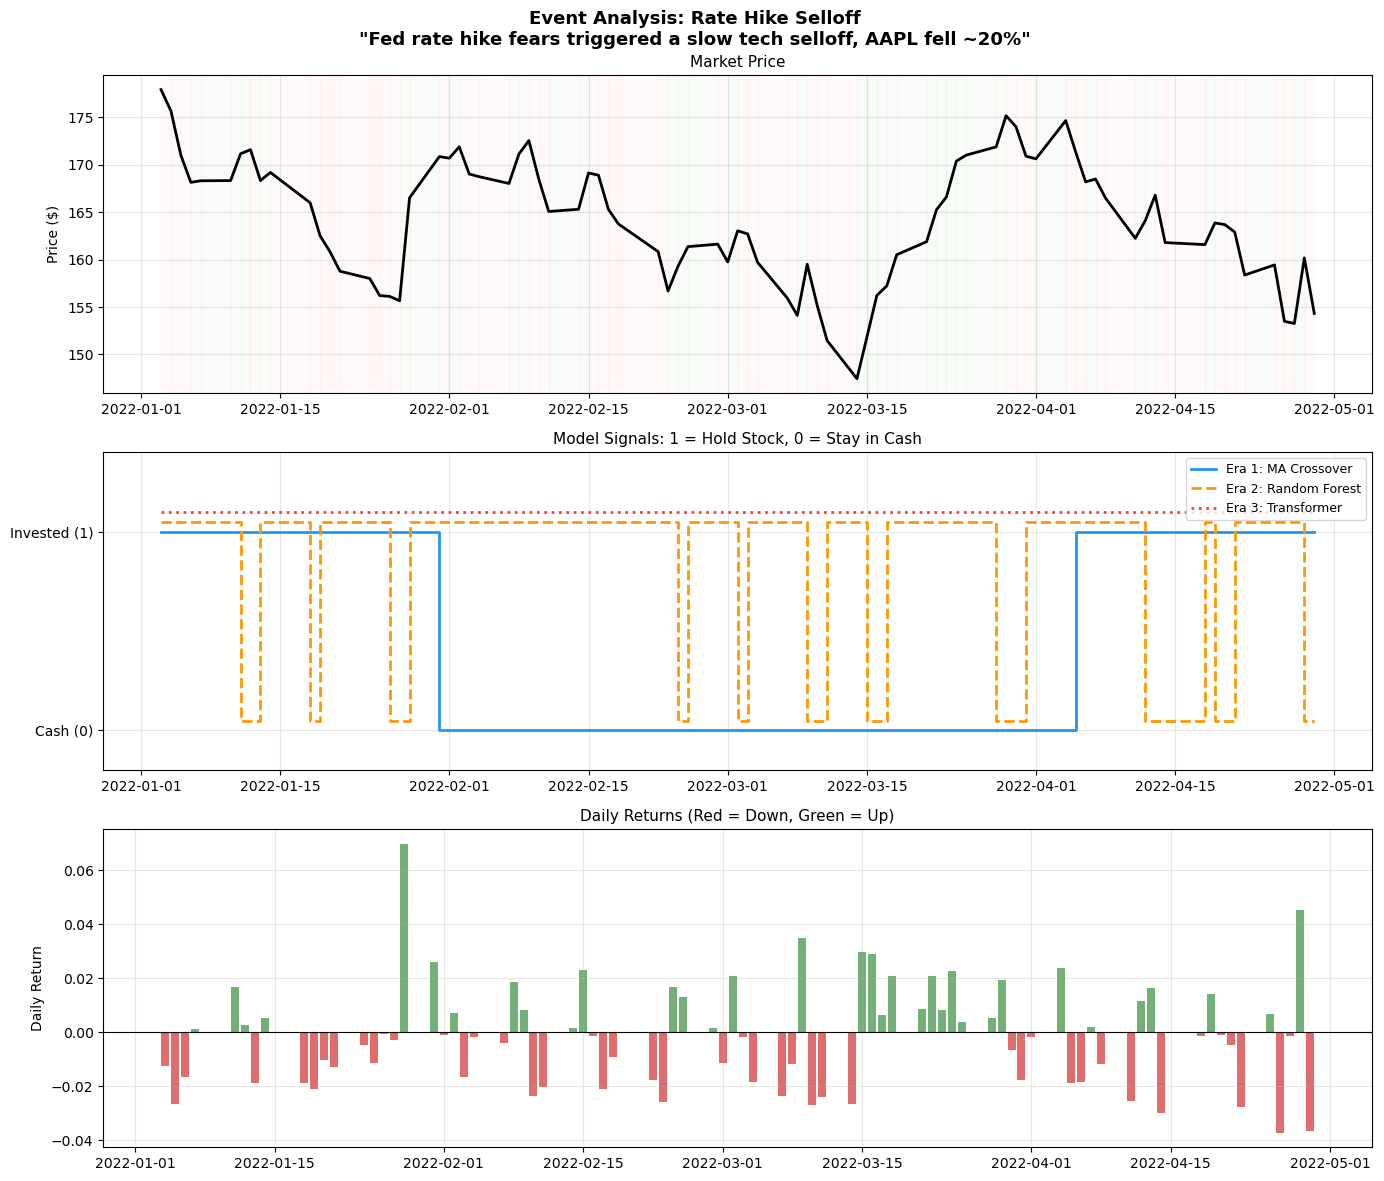


=== Rate Hike Selloff: Signal Statistics ===
Days invested - Era 1 (MA):          37 / 82 days
Days invested - Era 2 (RF):           61 / 82 days
Days invested - Era 3 (Transformer):  82 / 82 days
Actual price change during event:      -13.3%


In [10]:
# =============================================================
# EVENT 3: RATE HIKE SELLOFF
#
# What happened: The Fed signaled aggressive rate hikes in late 2021.
# Tech stocks sold off throughout 2022. Unlike COVID, this was
# a slow, grinding decline driven by macro factors - not a panic.
#
# What to look for:
# - Can any model distinguish this "slow burn" from noise?
# - Do the signals behave differently than during the COVID crash?
# =============================================================

analyze_event(
    event_name="Rate Hike Selloff",
    start_date="2022-01-01",
    end_date="2022-05-01",
    description="Fed rate hike fears triggered a slow tech selloff, AAPL fell ~20%",
    filename="14_event_rate_hike.png"
)

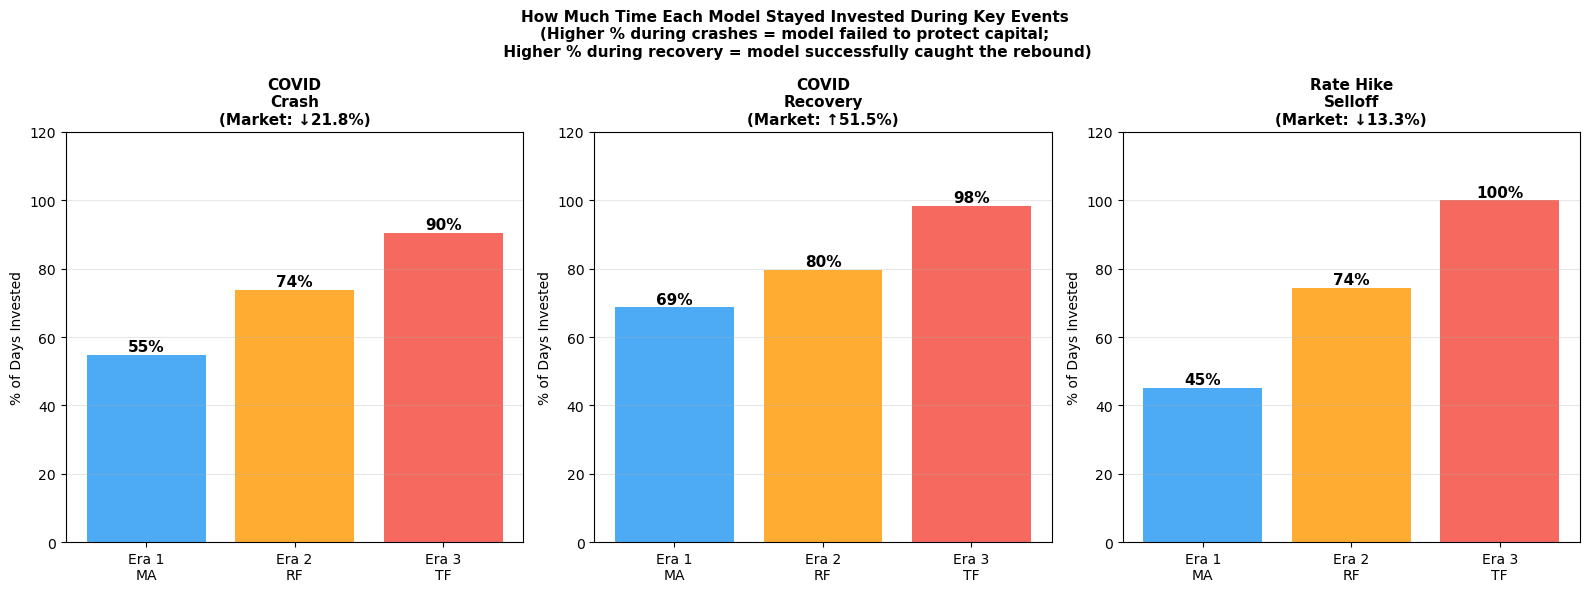

In [11]:
# =============================================================
# SUMMARY: Model Behavior Patterns Across All Three Events
#
# This final chart summarizes what we learned about each model's
# "personality" - how it tends to behave under stress.
#
# Key insight to look for:
# - Era 1 (MA): slow to react, but consistent
# - Era 2 (RF): fastest to react, but sometimes noisy
# - Era 3 (Transformer): most uncertain during high volatility
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

events = [
    ("COVID\nCrash", "2020-02-01", "2020-04-01"),
    ("COVID\nRecovery", "2020-04-01", "2020-07-01"),
    ("Rate Hike\nSelloff", "2022-01-01", "2022-05-01"),
]

for idx, (event_name, start, end) in enumerate(events):
    event_prices = prices[start:end]
    
    sig_ma = signal_ma.reindex(event_prices.index).fillna(method='ffill').fillna(0)
    sig_rf = signal_rf_full.reindex(event_prices.index).fillna(method='ffill').fillna(0)
    sig_tf = signal_tf_full.reindex(event_prices.index).fillna(method='ffill').fillna(0)
    
    n_days = len(event_prices)
    
    # Calculate % of days each model was invested
    pct_invested = {
        'Era 1\nMA': sig_ma.mean() * 100,
        'Era 2\nRF': sig_rf.mean() * 100,
        'Era 3\nTF': sig_tf.mean() * 100,
    }
    
    colors = ['#2196F3', '#FF9800', '#F44336']
    bars = axes[idx].bar(pct_invested.keys(),
                         pct_invested.values(),
                         color=colors, alpha=0.8)
    
    for bar, val in zip(bars, pct_invested.values()):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 1,
                      f'{val:.0f}%', ha='center',
                      fontweight='bold', fontsize=11)
    
    # Add actual price change as context
    price_change = (event_prices.iloc[-1] / event_prices.iloc[0] - 1) * 100
    direction = "↓" if price_change < 0 else "↑"
    axes[idx].set_title(f'{event_name}\n(Market: {direction}{abs(price_change):.1f}%)',
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('% of Days Invested')
    axes[idx].set_ylim(0, 120)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('How Much Time Each Model Stayed Invested During Key Events\n'
             '(Higher % during crashes = model failed to protect capital;\n'
             ' Higher % during recovery = model successfully caught the rebound)',
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/15_event_summary.png', dpi=150, bbox_inches='tight')
plt.show()